# Вторая часть домашнего задания

В этом ноутбуке собрана практическая часть задания на **собственных модулях** из `homework_modules.ipynb`.
Здесь я уже не проверяю отдельные слои по одному, а использую их в полноценных моделях и смотрю, как они ведут себя на реальных задачах.

Во второй части я последовательно решаю три постановки:

1. **мультирегрессия** на табличных данных;
2. **мультиклассовая классификация** на MNIST;
3. **автоэнкодер** для восстановления изображений.

Логика обучения во всех случаях одна и та же. На каждом шаге параметры модели обновляются по правилу

$$
\theta_{t+1}=\theta_t-\eta_t\,\nabla_{\theta}\mathcal{L}(\theta_t),
$$

где $\theta_t$ — вектор параметров на шаге $t$, $\eta_t$ — текущий learning rate, а $\mathcal{L}$ — выбранная функция потерь.

При этом сами задачи отличаются:

- в регрессии нужно приблизить непрерывный многомерный отклик;
- в классификации нужно оценить распределение вероятностей по 10 классам;
- в автоэнкодере модель учится отображению $x \mapsto \hat x$, то есть пытается восстановить вход после прохождения через сжатое представление.

По сути, цель этой части — показать, что реализованные в первой части слои действительно работают не изолированно, а как строительные блоки для реальных нейросетевых моделей.

## 1. Подключение модулей из первой части

Сначала я подгружаю ноутбук `homework_modules.ipynb`, в котором реализованы базовые строительные блоки: линейные и сверточные слои, контейнер `Sequential`, функции активации, pooling, нормализация и критерии качества.

Смысл этого шага простой: дальше все модели во второй части собираются **не на готовых high-level слоях**, а именно на тех классах, которые были написаны в первой части задания.

По сути, после выполнения следующей ячейки в среде появляются:

- собственные модули прямого прохода;
- методы обратного распространения градиента;
- контейнеры для последовательной сборки сети;
- критерии ошибки, с которыми уже можно запускать обучение.

Это важно и содержательно, и формально: вторая часть опирается на реализацию из первой, а не живёт отдельно от неё.



In [1]:
%run homework_modules.ipynb

## 2. Импорты и базовая настройка среды

Дальше подключаются библиотеки, которые нужны уже не для написания самих слоёв, а для полноценного эксперимента: подготовки данных, визуализации, сохранения результатов и работы с датасетами.

Здесь используются:

- `numpy` — основа всех вычислений, потому что мои модули принимают и возвращают именно numpy-массивы;
- `pandas` — для компактного вывода итоговых таблиц с результатами;
- `matplotlib` — для графиков лоссов, метрик и реконструкций;
- `sklearn` — для генерации мультирегрессионного датасета и корректного разбиения выборки;
- `pathlib`, `pickle`, `copy` — для работы с путями и сохранения лучшей модели;
- `torchvision.datasets` — только для получения MNIST.

Для классификации я использую именно `torchvision.datasets.MNIST(download=True)`. Это здесь единственное место, где нужен внешний датасетный интерфейс: дальше изображения сразу переводятся в `numpy` и вся логика обучения снова идёт на моих модулях.

Дополнительно я фиксирую `seed`, чтобы результаты были воспроизводимыми. Это особенно полезно там, где есть случайная инициализация весов, dropout и случайное разбиение данных.



In [2]:
import copy
import math
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from torchvision import datasets

np.random.seed(42)


C:\Users\gserb\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\gserb\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 3. Дополнительные модули и нелинейности

В первой части уже есть основной набор слоёв, но для полноценной второй части этого недостаточно. Как только начинается сборка нескольких архитектур, быстро становится ясно, что удобнее вынести часть повторяющейся логики в отдельные классы и функции.

В этой секции я добавляю именно такие элементы.

### Что здесь появляется

**Дополнительные функции активации.**  
Для регрессии я не ограничиваюсь одной нелинейностью. Полезно сравнить, как ведут себя разные функции:

- `ReLU` и `LeakyReLU` — базовые кусочно-линейные варианты;
- `ELU` — сглаженный вариант с отрицательной веткой;
- `SoftPlus` — мягкая версия ReLU;
- `Tanh` и `Sigmoid` — классические гладкие нелинейности;
- `GELU` — более современная гладкая активация.

Например,
$$
\sigma(x)=\frac{1}{1+e^{-x}},
$$
а для гиперболического тангенса
$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}.
$$

**Утилиты для сборки архитектур.**  
Ниже я буду много раз повторять одни и те же паттерны: линейный слой, нормализация, активация, dropout. Поэтому удобнее сразу собрать функции, которые будут создавать такие блоки программно, а не писать их каждый раз вручную.

**Дополнительные служебные компоненты.**  
Сюда же относятся небольшие вспомогательные классы и функции, которые упрощают сборку моделей и делают код второй части более аккуратным.

In [3]:

class Sigmoid(Module):
    def __init__(self):
        super(Sigmoid, self).__init__()

    def updateOutput(self, input):
        positive = input >= 0
        negative = ~positive
        self.output = np.empty_like(input, dtype=np.float32)
        self.output[positive] = 1.0 / (1.0 + np.exp(-input[positive]))
        exp_x = np.exp(input[negative])
        self.output[negative] = exp_x / (1.0 + exp_x)
        return self.output

    def updateGradInput(self, input, gradOutput):
        sig = self.output if self.output is not None and self.output.shape == input.shape else self.updateOutput(input)
        self.gradInput = gradOutput * sig * (1.0 - sig)
        return self.gradInput

    def __repr__(self):
        return 'Sigmoid'


class Tanh(Module):
    def __init__(self):
        super(Tanh, self).__init__()

    def updateOutput(self, input):
        self.output = np.tanh(input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        out = self.output if self.output is not None and self.output.shape == input.shape else self.updateOutput(input)
        self.gradInput = gradOutput * (1.0 - out ** 2)
        return self.gradInput

    def __repr__(self):
        return 'Tanh'


class Reshape(Module):
    def __init__(self, target_shape):
        super(Reshape, self).__init__()
        self.target_shape = tuple(target_shape)

    def updateOutput(self, input):
        self.output = input.reshape((input.shape[0],) + self.target_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(input.shape)
        return self.gradInput

    def __repr__(self):
        return f'Reshape{self.target_shape}'


class Upsample2d(Module):
    def __init__(self, scale_factor=2, mode='nearest'):
        super(Upsample2d, self).__init__()
        self.scale_factor = _pair(scale_factor)
        self.mode = mode

    def updateOutput(self, input):
        if self.mode != 'nearest':
            raise ValueError("This notebook uses only nearest-neighbor upsampling.")
        scale_h, scale_w = self.scale_factor
        self.output = np.repeat(np.repeat(input, scale_h, axis=2), scale_w, axis=3)
        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.mode != 'nearest':
            raise ValueError("This notebook uses only nearest-neighbor upsampling.")
        scale_h, scale_w = self.scale_factor
        n, c, h, w = input.shape
        self.gradInput = gradOutput.reshape(n, c, h, scale_h, w, scale_w).sum(axis=(3, 5))
        return self.gradInput

    def __repr__(self):
        return f"Upsample2d(scale_factor={self.scale_factor}, mode='{self.mode}')"

class SpatialBatchNorm(Module):
    """BatchNorm по каналам для NCHW через reshape -> BN -> reshape back."""
    def __init__(self, n_channels, alpha=0.9, affine=True):
        super(SpatialBatchNorm, self).__init__()
        self.n_channels = n_channels
        self.inner = Sequential()
        self.inner.add(BatchNormalization(alpha))
        if affine:
            self.inner.add(ChannelwiseScaling(n_channels))

    def _flatten_spatial(self, x):
        n, c, h, w = x.shape
        return x.transpose(0, 2, 3, 1).reshape(-1, c)

    def _restore_spatial(self, x, original_shape):
        n, c, h, w = original_shape
        return x.reshape(n, h, w, c).transpose(0, 3, 1, 2)

    def updateOutput(self, input):
        flat = self._flatten_spatial(input)
        out = self.inner.updateOutput(flat)
        self.output = self._restore_spatial(out, input.shape)
        return self.output

    def backward(self, input, gradOutput):
        flat_in = self._flatten_spatial(input)
        flat_grad = self._flatten_spatial(gradOutput)
        grad = self.inner.backward(flat_in, flat_grad)
        self.gradInput = self._restore_spatial(grad, input.shape)
        return self.gradInput

    def updateGradInput(self, input, gradOutput):
        return self.backward(input, gradOutput)

    def accGradParameters(self, input, gradOutput):
        pass

    def zeroGradParameters(self):
        self.inner.zeroGradParameters()

    def getParameters(self):
        return self.inner.getParameters()

    def getGradParameters(self):
        return self.inner.getGradParameters()

    def train(self):
        super(SpatialBatchNorm, self).train()
        self.inner.train()

    def evaluate(self):
        super(SpatialBatchNorm, self).evaluate()
        self.inner.evaluate()

    def __repr__(self):
        return 'SpatialBatchNorm'


## 4. Оптимизаторы, scheduler, warmup и early stopping

Здесь появляется уже не архитектура, а **механика обучения**. Одного умения посчитать `forward` и `backward` недостаточно: нужно ещё обновлять параметры, управлять learning rate и вовремя останавливать обучение, если модель перестала улучшаться.

### 4.1. Сбор параметров модели

Так как модель состоит из вложенных модулей, параметры и их градиенты хранятся не плоско. Поэтому сначала я делаю служебные функции, которые приводят эту структуру к удобному виду — списку массивов параметров и соответствующих им градиентов.

### 4.2. Оптимизаторы

Я использую две стандартные схемы обновления весов.

**SGD с momentum**:
$$
v_t = \mu v_{t-1} - \eta \nabla_{\theta}\mathcal{L}(\theta_t), \qquad
\theta_{t+1}=\theta_t+v_t.
$$

**Adam**:
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t,
$$
$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2,
$$
$$
\theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}.
$$

То есть я не использую готовый оптимизатор "из коробки", а реализую его так, чтобы он работал именно с моими классами и их параметрами.

### 4.3. Scheduler и warmup

В задании отдельно требуется наличие scheduler для learning rate и warmup. Идея здесь такая:

- сначала шаг обучения постепенно увеличивается до базового значения;
- затем по ходу обучения уменьшается по заранее заданному правилу.

Смысл в том, что слишком большой learning rate в самом начале может сделать обучение нестабильным, а слишком большой learning rate на поздних эпохах мешает аккуратно дойти до минимума.

### 4.4. Early stopping

Если валидационное качество долго не улучшается, нет смысла бесконечно продолжать эпохи. Поэтому я добавляю early stopping: обучение прекращается, когда модель перестаёт давать новый лучший результат на validation.

Одновременно сохраняется **лучшая версия модели**, чтобы тестовая проверка шла по действительно лучшему состоянию, а не просто по последней эпохе.

In [4]:

def _flatten_param_structure(structure):
    flat = []
    if isinstance(structure, list):
        for item in structure:
            flat.extend(_flatten_param_structure(item))
    elif isinstance(structure, np.ndarray):
        flat.append(structure)
    return flat


def collect_parameter_pairs(model):
    params = _flatten_param_structure(model.getParameters())
    grads = _flatten_param_structure(model.getGradParameters())
    return list(zip(params, grads))


class Optimizer:
    def __init__(self, model, lr=1e-3, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay

    def set_lr(self, lr):
        self.lr = lr

    def state_dict(self):
        return {'lr': self.lr, 'weight_decay': self.weight_decay}

    def step(self):
        raise NotImplementedError


class SGD(Optimizer):
    def __init__(self, model, lr=1e-2, momentum=0.0, weight_decay=0.0):
        super(SGD, self).__init__(model=model, lr=lr, weight_decay=weight_decay)
        self.momentum = momentum
        self.velocity = {}

    def step(self):
        for idx, (param, grad) in enumerate(collect_parameter_pairs(self.model)):
            if idx not in self.velocity:
                self.velocity[idx] = np.zeros_like(param)
            update = grad
            if self.weight_decay != 0.0:
                update = update + self.weight_decay * param
            self.velocity[idx] = self.momentum * self.velocity[idx] - self.lr * update
            param += self.velocity[idx]

    def state_dict(self):
        state = super(SGD, self).state_dict()
        state['momentum'] = self.momentum
        return state


class Adam(Optimizer):
    def __init__(self, model, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        super(Adam, self).__init__(model=model, lr=lr, weight_decay=weight_decay)
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self):
        self.t += 1
        for idx, (param, grad) in enumerate(collect_parameter_pairs(self.model)):
            if idx not in self.m:
                self.m[idx] = np.zeros_like(param)
                self.v[idx] = np.zeros_like(param)

            update = grad
            if self.weight_decay != 0.0:
                update = update + self.weight_decay * param

            self.m[idx] = self.beta1 * self.m[idx] + (1.0 - self.beta1) * update
            self.v[idx] = self.beta2 * self.v[idx] + (1.0 - self.beta2) * (update ** 2)

            m_hat = self.m[idx] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[idx] / (1.0 - self.beta2 ** self.t)
            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def state_dict(self):
        state = super(Adam, self).state_dict()
        state['betas'] = (self.beta1, self.beta2)
        state['eps'] = self.eps
        return state


OPTIMIZER_REGISTRY = {
    'sgd': SGD,
    'adam': Adam,
}


class WarmupThenStepScheduler:
    def __init__(self, optimizer, base_lr, warmup_epochs=3, step_size=10, gamma=0.5, min_lr=1e-5):
        self.optimizer = optimizer
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
        self.step_size = step_size
        self.gamma = gamma
        self.min_lr = min_lr

    def get_lr(self, epoch):
        if epoch < self.warmup_epochs:
            return max(self.min_lr, self.base_lr * float(epoch + 1) / float(max(1, self.warmup_epochs)))
        decay_steps = (epoch - self.warmup_epochs) // max(1, self.step_size)
        return max(self.min_lr, self.base_lr * (self.gamma ** decay_steps))

    def step(self, epoch):
        lr = self.get_lr(epoch)
        self.optimizer.set_lr(lr)
        return lr


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, mode='min', checkpoint_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.checkpoint_path = checkpoint_path

        self.best_score = None
        self.best_model = None
        self.best_epoch = None
        self.counter = 0
        self.should_stop = False

    def _is_improvement(self, score):
        if self.best_score is None:
            return True
        if self.mode == 'min':
            return score < self.best_score - self.min_delta
        return score > self.best_score + self.min_delta

    def step(self, score, model, epoch):
        if self._is_improvement(score):
            self.best_score = float(score)
            self.best_model = copy.deepcopy(model)
            self.best_epoch = epoch
            self.counter = 0
            if self.checkpoint_path is not None:
                try:
                    with open(self.checkpoint_path, 'wb') as f:
                        pickle.dump(self.best_model, f)
                except Exception:
                    # In some execution modes notebook-defined classes are not pickleable.
                    # The best model still stays available in memory via self.best_model.
                    pass
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


## 5. Метрики, функции потерь и общий цикл обучения

После того как готовы слои и оптимизация, нужно описать, **что именно считается ошибкой** и как измеряется качество модели на практике.

### 5.1. Функции потерь

Для регрессии и автоэнкодера я использую среднеквадратичную ошибку:

$$
\mathcal{L}_{MSE}=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat y_i)^2.
$$

Эта функция естественна там, где таргет непрерывен или где задача сводится к восстановлению входа.

Для классификации используется отрицательное логарифмическое правдоподобие:

$$
\mathcal{L}_{NLL}=-\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} y_{ik}\log p_{ik},
$$

где $y_{ik}$ — one-hot представление правильного класса, а $p_{ik}$ — предсказанная вероятность класса $k$ для объекта $i$.

### 5.2. Метрики

Лосс нужен для обучения, но в отчёте важно показывать и интерпретируемые показатели.

Для регрессии я считаю:

- **MSE**,
- **MAE**,
- коэффициент детерминации $R^2$.

Формулы здесь такие:

$$
MSE=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat y_i)^2,
$$

$$
MAE=\frac{1}{N}\sum_{i=1}^{N}|y_i-\hat y_i|,
$$

$$
R^2 = 1 - \frac{\sum_{i=1}^{N}(y_i-\hat y_i)^2}{\sum_{i=1}^{N}(y_i-\bar y)^2}.
$$

Для классификации основной метрикой служит accuracy:

$$
\mathrm{Accuracy}=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}(\hat c_i=c_i).
$$

Для автоэнкодера я снова смотрю на MSE реконструкции, потому что здесь важно, насколько близко восстановленное изображение к исходному.

### 5.3. Общий цикл обучения

Ниже я собираю единый тренировочный цикл: прохождение по мини-батчам, обновление параметров, расчёт train- и validation-метрик, шаг scheduler, проверка early stopping и сохранение истории обучения для графиков.

Это позволяет не писать отдельную логику заново под каждую модель.

In [5]:

def mse_metric(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def mae_metric(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def r2_metric(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2)
    return float(1.0 - ss_res / max(ss_tot, 1e-12))


def accuracy_metric(y_true_labels, y_pred_log_probs):
    pred_labels = np.argmax(y_pred_log_probs, axis=1)
    return float(np.mean(pred_labels == y_true_labels))


def reconstruction_mse_metric(y_true, y_pred):
    return mse_metric(y_true, y_pred)


CRITERION_REGISTRY = {
    'mse': MSECriterion,
    'nll': ClassNLLCriterion,
    'nll_unstable': ClassNLLCriterionUnstable,
}

METRIC_REGISTRY = {
    'mse': mse_metric,
    'mae': mae_metric,
    'r2': r2_metric,
    'accuracy': accuracy_metric,
    'reconstruction_mse': reconstruction_mse_metric,
}


def iterate_minibatches(X, y, batch_size, shuffle=True, seed=42):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    for start in range(0, n_samples, batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]


def evaluate_model(model, criterion, X, y, batch_size, metrics, task_type='regression', labels=None):
    model.evaluate()
    losses = []
    preds = []

    for x_batch, y_batch in iterate_minibatches(X, y, batch_size=batch_size, shuffle=False):
        output = model.forward(x_batch)
        losses.append(float(criterion.forward(output, y_batch)))
        preds.append(output)

    preds = np.concatenate(preds, axis=0)
    avg_loss = float(np.mean(losses)) if losses else np.nan

    results = {'loss': avg_loss}
    if task_type == 'regression':
        for metric_name in metrics:
            results[metric_name] = METRIC_REGISTRY[metric_name](y, preds)
    elif task_type == 'classification':
        for metric_name in metrics:
            if metric_name == 'accuracy':
                results[metric_name] = METRIC_REGISTRY[metric_name](labels, preds)
    elif task_type == 'autoencoder':
        for metric_name in metrics:
            results[metric_name] = METRIC_REGISTRY[metric_name](y, preds)
    return results, preds


def fit_model(
    model,
    criterion,
    optimizer,
    scheduler,
    early_stopper,
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size,
    n_epochs,
    metrics,
    task_type='regression',
    train_labels=None,
    val_labels=None,
    verbose=True,
):
    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    for metric_name in metrics:
        history[f'train_{metric_name}'] = []
        history[f'val_{metric_name}'] = []

    for epoch in range(n_epochs):
        model.train()
        current_lr = scheduler.step(epoch)
        history['lr'].append(current_lr)

        train_losses = []
        train_preds = []

        for x_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True, seed=42 + epoch):
            model.zeroGradParameters()
            output = model.forward(x_batch)
            loss = criterion.forward(output, y_batch)
            grad_output = criterion.backward(output, y_batch)
            model.backward(x_batch, grad_output)
            optimizer.step()

            train_losses.append(float(loss))
            train_preds.append(output)

        train_preds = np.concatenate(train_preds, axis=0)
        train_loss = float(np.mean(train_losses)) if train_losses else np.nan
        history['train_loss'].append(train_loss)

        train_results = {'loss': train_loss}
        if task_type == 'regression':
            for metric_name in metrics:
                train_results[metric_name] = METRIC_REGISTRY[metric_name](y_train, train_preds)
        elif task_type == 'classification':
            for metric_name in metrics:
                if metric_name == 'accuracy':
                    train_results[metric_name] = METRIC_REGISTRY[metric_name](train_labels, train_preds)
        elif task_type == 'autoencoder':
            for metric_name in metrics:
                train_results[metric_name] = METRIC_REGISTRY[metric_name](y_train, train_preds)

        val_results, _ = evaluate_model(
            model=model,
            criterion=criterion,
            X=X_val,
            y=y_val,
            batch_size=batch_size,
            metrics=metrics,
            task_type=task_type,
            labels=val_labels,
        )
        history['val_loss'].append(val_results['loss'])

        for metric_name in metrics:
            history[f'train_{metric_name}'].append(train_results[metric_name])
            history[f'val_{metric_name}'].append(val_results[metric_name])

        early_stopper.step(val_results['loss'], model, epoch)
        if verbose:
            metric_log = ', '.join([
                f"{m}: train={train_results[m]:.4f} | val={val_results[m]:.4f}" for m in metrics
            ])
            print(
                f"Epoch {epoch + 1:03d}/{n_epochs:03d} | "
                f"lr={current_lr:.6f} | "
                f"loss: train={train_loss:.4f} | val={val_results['loss']:.4f}"
                + (f" | {metric_log}" if metric_log else '')
            )

        if early_stopper.should_stop:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch + 1}. Best epoch: {early_stopper.best_epoch + 1}")
            break

    best_model = early_stopper.best_model if early_stopper.best_model is not None else copy.deepcopy(model)
    return history, best_model



## 6. Визуализация результатов

Сами по себе финальные числа полезны, но без графиков по ним трудно понять, **как именно** шло обучение.
Например, две модели могут дать близкий тестовый результат, но одна из них могла выйти на хорошее качество стабильно, а другая — через сильные колебания и переобучение.

Поэтому ниже я выношу визуализацию в отдельные функции.

### Что здесь показывается

**Кривые train / validation loss.**  
Они позволяют увидеть, улучшается ли модель действительно осмысленно, а не только на обучающей выборке.

**Динамика метрик по эпохам.**  
Для регрессии это, например, MSE, MAE и $R^2$; для классификации — accuracy; для автоэнкодера — MSE реконструкции.

**История learning rate.**  
Так как в ноутбуке есть warmup и scheduler, полезно видеть не только ошибку, но и траекторию изменения шага обучения.

**Реконструкции автоэнкодера.**  
В задаче восстановления изображения численного значения недостаточно. Даже если MSE у двух моделей близка, визуально реконструкции могут заметно различаться. Поэтому я отдельно показываю пары
$$
(x,\hat x),
$$
чтобы сравнить оригинал и выход модели напрямую.

Эта секция делает анализ результатов намного более прозрачным: становится видно не только "какая цифра получилась в конце", но и как модель к ней пришла.



In [6]:

def plot_history(history, metric_names, title_prefix='Model'):
    n_rows = 1 + len(metric_names)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4 * n_rows))
    if n_rows == 1:
        axes = [axes]

    axes[0].plot(history['train_loss'], label='train loss')
    axes[0].plot(history['val_loss'], label='val loss')
    axes[0].plot(history['lr'], label='lr')
    axes[0].set_title(f'{title_prefix}: loss / lr')
    axes[0].set_xlabel('epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for idx, metric_name in enumerate(metric_names, start=1):
        axes[idx].plot(history[f'train_{metric_name}'], label=f'train {metric_name}')
        axes[idx].plot(history[f'val_{metric_name}'], label=f'val {metric_name}')
        axes[idx].set_title(f'{title_prefix}: {metric_name}')
        axes[idx].set_xlabel('epoch')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def show_reconstructions(inputs, reconstructions, n_examples=8, cmap='gray'):
    n_examples = min(n_examples, len(inputs))
    fig, axes = plt.subplots(2, n_examples, figsize=(2.0 * n_examples, 4))
    for i in range(n_examples):
        axes[0, i].imshow(inputs[i, 0], cmap=cmap)
        axes[0, i].axis('off')
        axes[0, i].set_title('original')
        axes[1, i].imshow(reconstructions[i, 0], cmap=cmap)
        axes[1, i].axis('off')
        axes[1, i].set_title('recon')
    plt.tight_layout()
    plt.show()


## 7. Сборка архитектур

После служебных функций можно переходить к самим моделям. Чтобы не писать каждую архитектуру вручную заново, я делаю отдельные функции-конструкторы. Это заметно упрощает экспериментальную часть: конфигурации легче сравнивать, а структура модели остаётся читаемой.

### 7.1. Сети для мультирегрессии

Здесь используются полносвязные сети (`FCNN`) разного размера. Их идея проста: последовательность линейных преобразований и нелинейностей отображает вектор признаков в несколько непрерывных выходов.

В общем виде блок можно описать как

$$
h^{(l+1)} = \phi\left(W^{(l)} h^{(l)} + b^{(l)}\right),
$$

где $\phi$ — функция активации.

### 7.2. Сверточный классификатор для MNIST

Для распознавания цифр я использую сверточную архитектуру. Это естественный выбор для изображений, потому что свёртки выделяют локальные признаки, pooling уменьшает размер карты признаков, а затем `Flatten` и полносвязный блок переводят всё в вероятности классов.

### 7.3. Автоэнкодер

Здесь модель состоит из двух частей:

- **encoder** переводит вход в более компактное латентное представление;
- **decoder** восстанавливает изображение обратно.

Если записать идею совсем кратко, то автоэнкодер реализует отображение

$$
x \rightarrow z \rightarrow \hat x,
$$

где $z$ — скрытое компактное представление объекта.

In [7]:

def make_activation(name):
    name = name.lower()
    if name == 'relu':
        return ReLU()
    if name == 'leaky_relu':
        return LeakyReLU(0.1)
    if name == 'elu':
        return ELU(1.0)
    if name == 'softplus':
        return SoftPlus()
    if name == 'gelu':
        return Gelu()
    if name == 'tanh':
        return Tanh()
    if name == 'sigmoid':
        return Sigmoid()
    raise ValueError(f'Unknown activation: {name}')


def add_dense_block(model, in_features, out_features, activation='relu', dropout_p=0.0, use_batchnorm=True, bn_alpha=0.9):
    model.add(Linear(in_features, out_features))
    if use_batchnorm:
        model.add(BatchNormalization(bn_alpha))
        model.add(ChannelwiseScaling(out_features))
    model.add(make_activation(activation))
    if dropout_p > 0.0:
        model.add(Dropout(dropout_p))


def build_regression_model(input_dim, output_dim, hidden_dims, activation='relu', dropout_p=0.1, use_batchnorm=True):
    model = Sequential()
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        add_dense_block(
            model=model,
            in_features=prev_dim,
            out_features=hidden_dim,
            activation=activation,
            dropout_p=dropout_p,
            use_batchnorm=use_batchnorm,
        )
        prev_dim = hidden_dim
    model.add(Linear(prev_dim, output_dim))
    return model


def compute_flatten_dim(model, input_shape):
    dummy = np.zeros((1,) + tuple(input_shape), dtype=np.float32)
    out = model.updateOutput(dummy)
    return out.shape[1]


def build_classifier_model(input_shape, n_classes=10, activation='leaky_relu', dropout_p=0.2):
    features = Sequential()
    features.add(Conv2d(input_shape[0], 8, kernel_size=3, stride=1, padding='same', bias=True))
    features.add(SpatialBatchNorm(8, alpha=0.9, affine=True))
    features.add(make_activation(activation))
    features.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    features.add(Conv2d(8, 16, kernel_size=3, stride=1, padding='same', bias=True))
    features.add(SpatialBatchNorm(16, alpha=0.9, affine=True))
    features.add(make_activation(activation))
    features.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    probe = Sequential()
    probe.add(features)
    probe.add(Flatten(start_dim=1, end_dim=-1))
    flatten_dim = compute_flatten_dim(probe, input_shape)

    classifier = Sequential()
    classifier.add(features)
    classifier.add(Flatten(start_dim=1, end_dim=-1))
    add_dense_block(
        model=classifier,
        in_features=flatten_dim,
        out_features=64,
        activation=activation,
        dropout_p=dropout_p,
        use_batchnorm=True,
    )
    classifier.add(Linear(64, n_classes))
    classifier.add(LogSoftMax())
    return classifier


def build_autoencoder(input_shape, latent_dim=32, activation='leaky_relu', dropout_p=0.1):
    c, h, w = input_shape

    encoder_features = Sequential()
    encoder_features.add(Conv2d(c, 8, kernel_size=3, stride=1, padding='same', bias=True))
    encoder_features.add(SpatialBatchNorm(8, alpha=0.9, affine=True))
    encoder_features.add(make_activation(activation))
    if dropout_p > 0:
        encoder_features.add(Dropout(dropout_p))
    encoder_features.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    encoder_features.add(Conv2d(8, 16, kernel_size=3, stride=1, padding='same', bias=True))
    encoder_features.add(SpatialBatchNorm(16, alpha=0.9, affine=True))
    encoder_features.add(make_activation(activation))
    if dropout_p > 0:
        encoder_features.add(Dropout(dropout_p))
    encoder_features.add(MaxPool2d(kernel_size=2, stride=2, padding=0))

    encoder_probe = Sequential()
    encoder_probe.add(encoder_features)
    encoder_probe.add(Flatten(start_dim=1, end_dim=-1))
    flatten_dim = compute_flatten_dim(encoder_probe, input_shape)

    spatial_h = max(1, h // 4)
    spatial_w = max(1, w // 4)

    model = Sequential()
    model.add(encoder_features)
    model.add(Flatten(start_dim=1, end_dim=-1))
    add_dense_block(
        model=model,
        in_features=flatten_dim,
        out_features=latent_dim,
        activation=activation,
        dropout_p=dropout_p,
        use_batchnorm=True,
    )
    add_dense_block(
        model=model,
        in_features=latent_dim,
        out_features=flatten_dim,
        activation=activation,
        dropout_p=0.0,
        use_batchnorm=True,
    )
    model.add(Reshape((16, spatial_h, spatial_w)))
    model.add(Upsample2d(scale_factor=2, mode='nearest'))
    model.add(Conv2d(16, 8, kernel_size=3, stride=1, padding='same', bias=True))
    model.add(SpatialBatchNorm(8, alpha=0.9, affine=True))
    model.add(make_activation(activation))
    model.add(Upsample2d(scale_factor=2, mode='nearest'))
    model.add(Conv2d(8, c, kernel_size=3, stride=1, padding='same', bias=True))
    model.add(Sigmoid())
    return model


## 8. Подготовка данных

Теперь нужно подготовить данные под каждую задачу. Хотя дальше модели будут разными, требования к данным общие: аккуратное разбиение на train / validation / test, корректные размерности и отсутствие утечки информации.

### 8.1. Мультирегрессия

Для регрессии я использую синтетический многомерный датасет. Это удобно, потому что можно сразу задать нужную структуру задачи: несколько признаков и несколько непрерывных целевых переменных.

Ключевой момент здесь — стандартизация признаков по статистикам **только train-выборки**:

$$
\tilde x = \frac{x-\mu_{train}}{\sigma_{train}}.
$$

Такой подход нужен, чтобы в preprocessing не просочилась информация из validation и test.

Целевые переменные я тоже масштабирую по train-части. Это облегчает обучение сети и делает градиенты более стабильными.

### 8.2. Классификация

Для классификации используется **MNIST**, загруженный через `torchvision.datasets.MNIST(download=True)`.

То есть здесь я не читаю файлы вручную и не использую запасные датасеты. Ноутбук сразу берёт стандартный MNIST через `torchvision`, после чего я перевожу изображения и метки в `numpy`, потому что дальше вся собственная модельная логика у меня работает именно на `numpy`-массивах.

Изображения нормируются в диапазон $[0,1]$, а затем при необходимости разбиваются на train / validation / test.

### 8.3. Автоэнкодер

Для автоэнкодера я использую изображения той же природы, что и в задаче классификации. Это удобно: модель учится не распознавать цифру, а восстанавливать сам входной образ после прохождения через узкое скрытое пространство.

In [8]:
def standardize_from_train(X_train, X_other):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    return (X_train - mean) / std, (X_other - mean) / std, mean, std


def prepare_multiregression_data(random_state=42):
    X, y = make_regression(
        n_samples=3200,
        n_features=20,
        n_informative=15,
        n_targets=3,
        noise=12.0,
        random_state=random_state,
    )
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=random_state)

    X_train_std, X_val_std, _, _ = standardize_from_train(X_train, X_val)
    _, X_test_std, _, _ = standardize_from_train(X_train, X_test)

    y_train_mean = y_train.mean(axis=0, keepdims=True)
    y_train_std = y_train.std(axis=0, keepdims=True)
    y_train_std = np.where(y_train_std < 1e-8, 1.0, y_train_std)

    y_train_scaled = (y_train - y_train_mean) / y_train_std
    y_val_scaled = (y_val - y_train_mean) / y_train_std
    y_test_scaled = (y_test - y_train_mean) / y_train_std

    return {
        'dataset_name': 'synthetic multi-target regression',
        'X_train': X_train_std.astype(np.float32),
        'X_val': X_val_std.astype(np.float32),
        'X_test': X_test_std.astype(np.float32),
        'y_train': y_train_scaled.astype(np.float32),
        'y_val': y_val_scaled.astype(np.float32),
        'y_test': y_test_scaled.astype(np.float32),
        'y_train_raw': y_train.astype(np.float32),
        'y_val_raw': y_val.astype(np.float32),
        'y_test_raw': y_test.astype(np.float32),
        'y_mean': y_train_mean.astype(np.float32),
        'y_std': y_train_std.astype(np.float32),
        'input_dim': X_train.shape[1],
        'output_dim': y_train.shape[1],
    }


def one_hot(labels, n_classes):
    out = np.zeros((labels.shape[0], n_classes), dtype=np.float32)
    out[np.arange(labels.shape[0]), labels] = 1.0
    return out


def _take_subset(X, y, max_size, random_state=42):
    if max_size is None or len(X) <= max_size:
        return X, y
    rng = np.random.RandomState(random_state)
    indices = []
    for label in np.unique(y):
        label_idx = np.where(y == label)[0]
        take = max(1, int(round(max_size * len(label_idx) / len(y))))
        chosen = rng.choice(label_idx, size=min(take, len(label_idx)), replace=False)
        indices.append(chosen)
    indices = np.concatenate(indices)
    if len(indices) > max_size:
        rng.shuffle(indices)
        indices = indices[:max_size]
    else:
        remaining = np.setdiff1d(np.arange(len(y)), indices, assume_unique=False)
        if len(indices) < max_size and len(remaining) > 0:
            extra = rng.choice(remaining, size=min(max_size - len(indices), len(remaining)), replace=False)
            indices = np.concatenate([indices, extra])
    rng.shuffle(indices)
    return X[indices], y[indices]



def load_mnist_via_torchvision(mnist_dir='.', max_train=2400, max_val=600, max_test=1000, random_state=42):
    root = Path(mnist_dir).resolve()

    train_dataset = datasets.MNIST(root=str(root), train=True, download=True)
    test_dataset = datasets.MNIST(root=str(root), train=False, download=True)

    X_train_full = train_dataset.data.numpy().astype(np.float32) / 255.0
    y_train_full = train_dataset.targets.numpy().astype(np.int64)
    X_test = test_dataset.data.numpy().astype(np.float32) / 255.0
    y_test = test_dataset.targets.numpy().astype(np.int64)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=random_state
    )

    X_train, y_train = _take_subset(X_train, y_train, max_train, random_state=42)
    X_val, y_val = _take_subset(X_val, y_val, max_val, random_state=43)
    X_test, y_test = _take_subset(X_test, y_test, max_test, random_state=44)

    X_train = X_train[:, None, :, :]
    X_val = X_val[:, None, :, :]
    X_test = X_test[:, None, :, :]

    return {
        'dataset_name': 'MNIST (torchvision.datasets.MNIST)',
        'X_train': X_train.astype(np.float32),
        'X_val': X_val.astype(np.float32),
        'X_test': X_test.astype(np.float32),
        'y_train_labels': y_train.astype(np.int64),
        'y_val_labels': y_val.astype(np.int64),
        'y_test_labels': y_test.astype(np.int64),
        'y_train': one_hot(y_train, 10),
        'y_val': one_hot(y_val, 10),
        'y_test': one_hot(y_test, 10),
        'input_shape': X_train.shape[1:],
        'n_classes': 10,
    }


def prepare_image_data(random_state=42, mnist_dir='.'):
    return load_mnist_via_torchvision(
        mnist_dir=mnist_dir,
        max_train=2400,
        max_val=600,
        max_test=1000,
        random_state=random_state,
    )


## 9. Сценарии экспериментов

До этого момента в ноутбуке были подготовлены все кирпичики: слои, оптимизаторы, scheduler, метрики, функции визуализации и данные. Ниже начинается уже прикладная часть — запуск самих экспериментов.

Я разбиваю её на отдельные функции по задачам. Это удобнее, чем писать всё в одну длинную ячейку:

- можно запускать задачи независимо;
- проще сравнивать результаты;
- легче читать код;
- при необходимости удобно повторять отдельный эксперимент с новыми параметрами.

### Что именно запускается

**Мультирегрессия.**  
Сравниваются несколько FCNN разного размера и с разными активациями.

**Классификация на MNIST.**  
Обучается сверточная модель и оценивается по accuracy и лоссу на тестовой выборке.

**Автоэнкодер.**  
Смотрю и на численную ошибку реконструкции, и на визуальное качество восстановленных изображений.

В этих сценариях уже используется вся инфраструктура сверху: сохранение лучшей модели, ранняя остановка, графики истории обучения и финальная оценка на test. Именно здесь ноутбук превращается в законченную лабораторную работу, а не просто набор вспомогательных функций.



In [9]:

def build_optimizer(name, model, lr, **kwargs):
    return OPTIMIZER_REGISTRY[name](model=model, lr=lr, **kwargs)


def run_regression_experiments(save_dir='part2_saved_models', verbose=False):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    data = prepare_multiregression_data()
    print(f"Using dataset: {data['dataset_name']}")

    size_configs = {
        'small': [32, 16],
        'medium': [64, 32, 16],
        'large': [128, 64, 32, 16],
    }
    activation_grid = ['relu', 'leaky_relu', 'elu']
    reports = {}

    for size_name, hidden_dims in size_configs.items():
        for activation_name in activation_grid:
            run_name = f'regression_{size_name}_{activation_name}'
            print(f"\n===== {run_name} =====")

            model = build_regression_model(
                input_dim=data['input_dim'],
                output_dim=data['output_dim'],
                hidden_dims=hidden_dims,
                activation=activation_name,
                dropout_p=0.10,
                use_batchnorm=True,
            )
            criterion = CRITERION_REGISTRY['mse']()
            optimizer = build_optimizer('adam', model, lr=1e-3, weight_decay=1e-4)
            scheduler = WarmupThenStepScheduler(optimizer, base_lr=1e-3, warmup_epochs=2, step_size=4, gamma=0.5)
            stopper = EarlyStopping(
                patience=4,
                min_delta=1e-4,
                mode='min',
                checkpoint_path=str(Path(save_dir) / f'{run_name}.pkl'),
            )

            history, best_model = fit_model(
                model=model,
                criterion=criterion,
                optimizer=optimizer,
                scheduler=scheduler,
                early_stopper=stopper,
                X_train=data['X_train'],
                y_train=data['y_train'],
                X_val=data['X_val'],
                y_val=data['y_val'],
                batch_size=96,
                n_epochs=8,
                metrics=['mse', 'mae', 'r2'],
                task_type='regression',
                verbose=verbose,
            )

            test_results_scaled, test_preds_scaled = evaluate_model(
                model=best_model,
                criterion=criterion,
                X=data['X_test'],
                y=data['y_test'],
                batch_size=256,
                metrics=['mse', 'mae', 'r2'],
                task_type='regression',
            )

            y_pred_test = test_preds_scaled * data['y_std'] + data['y_mean']
            y_true_test = data['y_test_raw']
            raw_mse = mse_metric(y_true_test, y_pred_test)
            raw_mae = mae_metric(y_true_test, y_pred_test)
            raw_r2 = r2_metric(y_true_test, y_pred_test)

            reports[run_name] = {
                'history': history,
                'best_epoch': stopper.best_epoch,
                'scaled_test': test_results_scaled,
                'raw_test': {'mse': raw_mse, 'mae': raw_mae, 'r2': raw_r2},
            }

            print(f'Test metrics (raw targets): MSE={raw_mse:.4f}, MAE={raw_mae:.4f}, R2={raw_r2:.4f}')
            plot_history(history, ['mse', 'mae', 'r2'], title_prefix=run_name)

    return reports


def run_classifier_experiment(save_dir='part2_saved_models', verbose=False):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    data = prepare_image_data()
    print(f"Using dataset: {data['dataset_name']}")

    model = build_classifier_model(
        input_shape=data['input_shape'],
        n_classes=data['n_classes'],
        activation='leaky_relu',
        dropout_p=0.20,
    )
    criterion = CRITERION_REGISTRY['nll']()
    optimizer = build_optimizer('adam', model, lr=1e-3, weight_decay=1e-4)
    scheduler = WarmupThenStepScheduler(optimizer, base_lr=1e-3, warmup_epochs=2, step_size=3, gamma=0.5)
    stopper = EarlyStopping(
        patience=4,
        min_delta=1e-4,
        mode='min',
        checkpoint_path=str(Path(save_dir) / 'classifier.pkl'),
    )

    history, best_model = fit_model(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        early_stopper=stopper,
        X_train=data['X_train'],
        y_train=data['y_train'],
        X_val=data['X_val'],
        y_val=data['y_val'],
        batch_size=48,
        n_epochs=6,
        metrics=['accuracy'],
        task_type='classification',
        train_labels=data['y_train_labels'],
        val_labels=data['y_val_labels'],
        verbose=verbose,
    )

    test_results, _ = evaluate_model(
        model=best_model,
        criterion=criterion,
        X=data['X_test'],
        y=data['y_test'],
        batch_size=96,
        metrics=['accuracy'],
        task_type='classification',
        labels=data['y_test_labels'],
    )

    print(f"Test loss={test_results['loss']:.4f}, test accuracy={test_results['accuracy']:.4f}")
    plot_history(history, ['accuracy'], title_prefix='classifier')

    return {
        'dataset_name': data['dataset_name'],
        'history': history,
        'test_results': test_results,
        'best_epoch': stopper.best_epoch,
    }


def run_autoencoder_experiment(save_dir='part2_saved_models', verbose=False):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    data = prepare_image_data()
    print(f"Using dataset: {data['dataset_name']}")

    model = build_autoencoder(
        input_shape=data['input_shape'],
        latent_dim=32,
        activation='leaky_relu',
        dropout_p=0.10,
    )
    criterion = CRITERION_REGISTRY['mse']()
    optimizer = build_optimizer('adam', model, lr=1e-3, weight_decay=1e-4)
    scheduler = WarmupThenStepScheduler(optimizer, base_lr=1e-3, warmup_epochs=2, step_size=3, gamma=0.5)
    stopper = EarlyStopping(
        patience=4,
        min_delta=1e-4,
        mode='min',
        checkpoint_path=str(Path(save_dir) / 'autoencoder.pkl'),
    )

    history, best_model = fit_model(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        early_stopper=stopper,
        X_train=data['X_train'],
        y_train=data['X_train'],
        X_val=data['X_val'],
        y_val=data['X_val'],
        batch_size=48,
        n_epochs=6,
        metrics=['reconstruction_mse'],
        task_type='autoencoder',
        verbose=verbose,
    )

    test_results, reconstructions = evaluate_model(
        model=best_model,
        criterion=criterion,
        X=data['X_test'],
        y=data['X_test'],
        batch_size=96,
        metrics=['reconstruction_mse'],
        task_type='autoencoder',
    )

    print(
        f"Test loss={test_results['loss']:.4f}, "
        f"test reconstruction MSE={test_results['reconstruction_mse']:.4f}"
    )
    plot_history(history, ['reconstruction_mse'], title_prefix='autoencoder')
    show_reconstructions(data['X_test'], reconstructions, n_examples=8)

    return {
        'dataset_name': data['dataset_name'],
        'history': history,
        'test_results': test_results,
        'best_epoch': stopper.best_epoch,
    }


def summarize_regression_reports(reports):
    rows = []
    for name, report in reports.items():
        rows.append({
            'run': name,
            'best_epoch': None if report['best_epoch'] is None else report['best_epoch'] + 1,
            'mse': report['raw_test']['mse'],
            'mae': report['raw_test']['mae'],
            'r2': report['raw_test']['r2'],
        })
    return pd.DataFrame(rows).sort_values(['mse', 'mae']).reset_index(drop=True)






## 10. Финальный запуск

Ниже находится итоговая ячейка, которая последовательно запускает все три части работы:

1. обучение моделей для мультирегрессии;
2. обучение сверточного классификатора на MNIST;
3. обучение автоэнкодера и вывод реконструкций.

После выполнения ячейки ноутбук:

- обучает модели;
- сохраняет лучшие состояния;
- строит графики train / validation;
- считает метрики на тестовой выборке;
- выводит итоговые таблицы для сравнения.

Отдельно подчеркну, что оценка идёт не только по одной финальной цифре. Я смотрю сразу на несколько вещей:

- как ведёт себя лосс по эпохам;
- насколько устойчиво модель учится;
- есть ли расхождение между train и validation;
- что получается на test;
- как выглядят реконструкции в задаче автоэнкодера.

Именно этот блок завершает всю вторую часть и собирает её в один воспроизводимый сценарий.



### Запуск всех экспериментов

В этой ячейке я последовательно вызываю функции для трёх задач. Папка `part2_saved_models` создаётся автоматически и используется для сохранения лучшей версии каждой модели по валидационному качеству.

Если ноутбук запускается целиком сверху вниз, дополнительных настроек здесь уже не требуется: все необходимые параметры заданы прямо внутри сценариев обучения.



Using dataset: synthetic multi-target regression

===== regression_small_relu =====
Test metrics (raw targets): MSE=18043.6275, MAE=102.8458, R2=0.6852


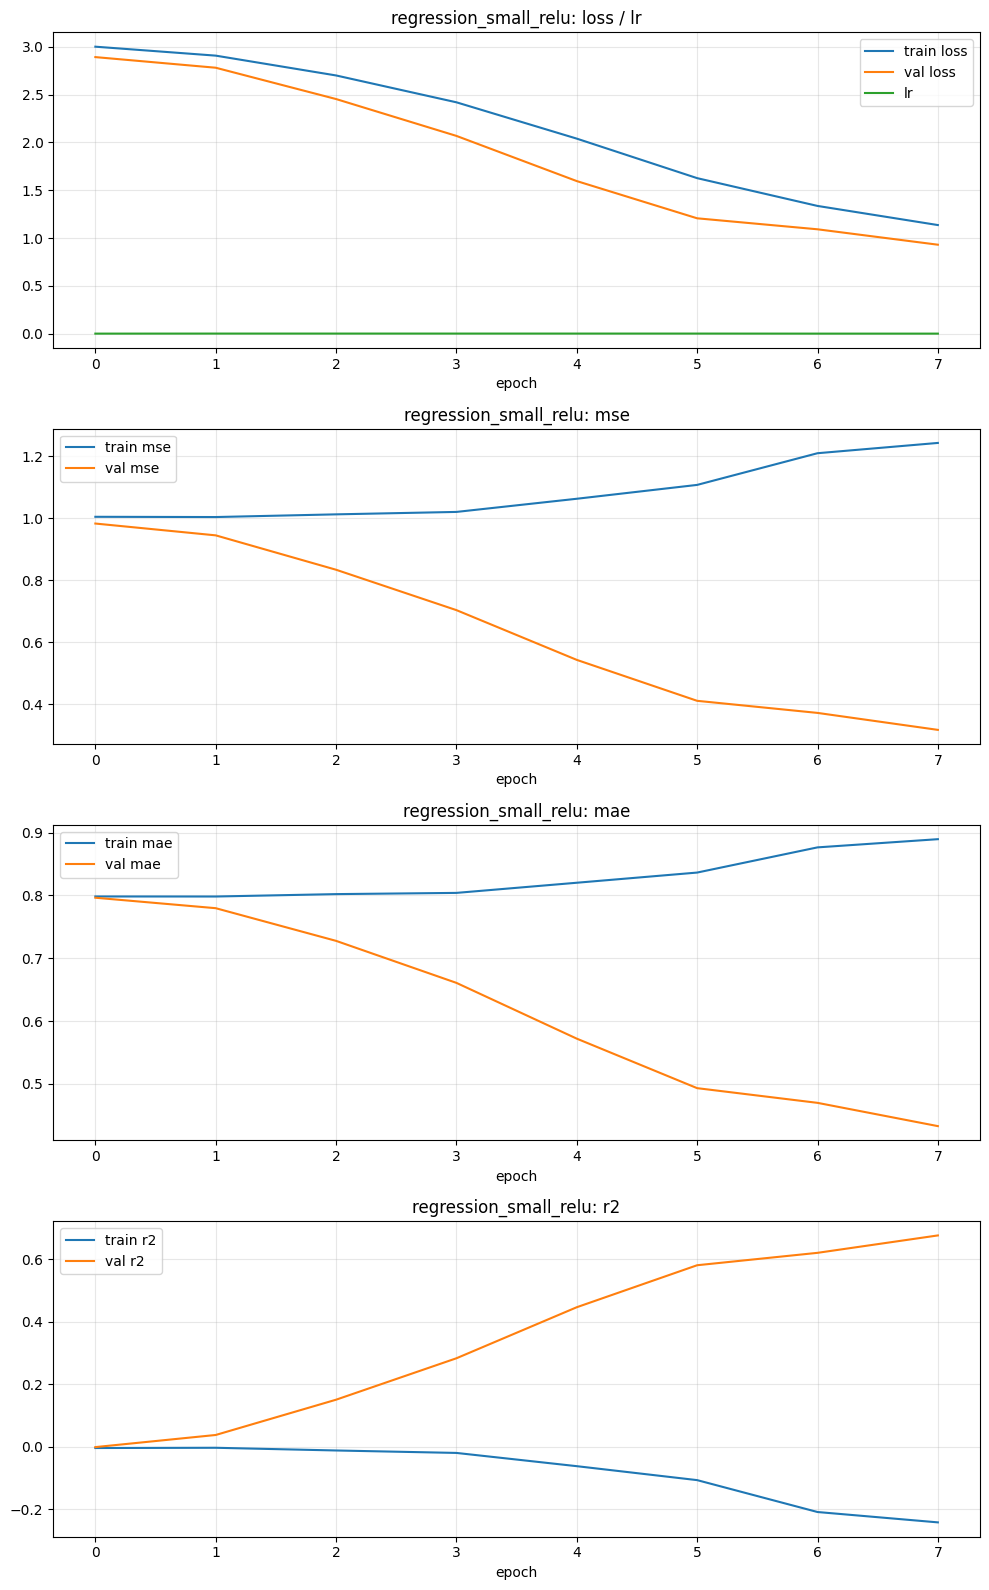


===== regression_small_leaky_relu =====
Test metrics (raw targets): MSE=13833.5230, MAE=86.6155, R2=0.7586


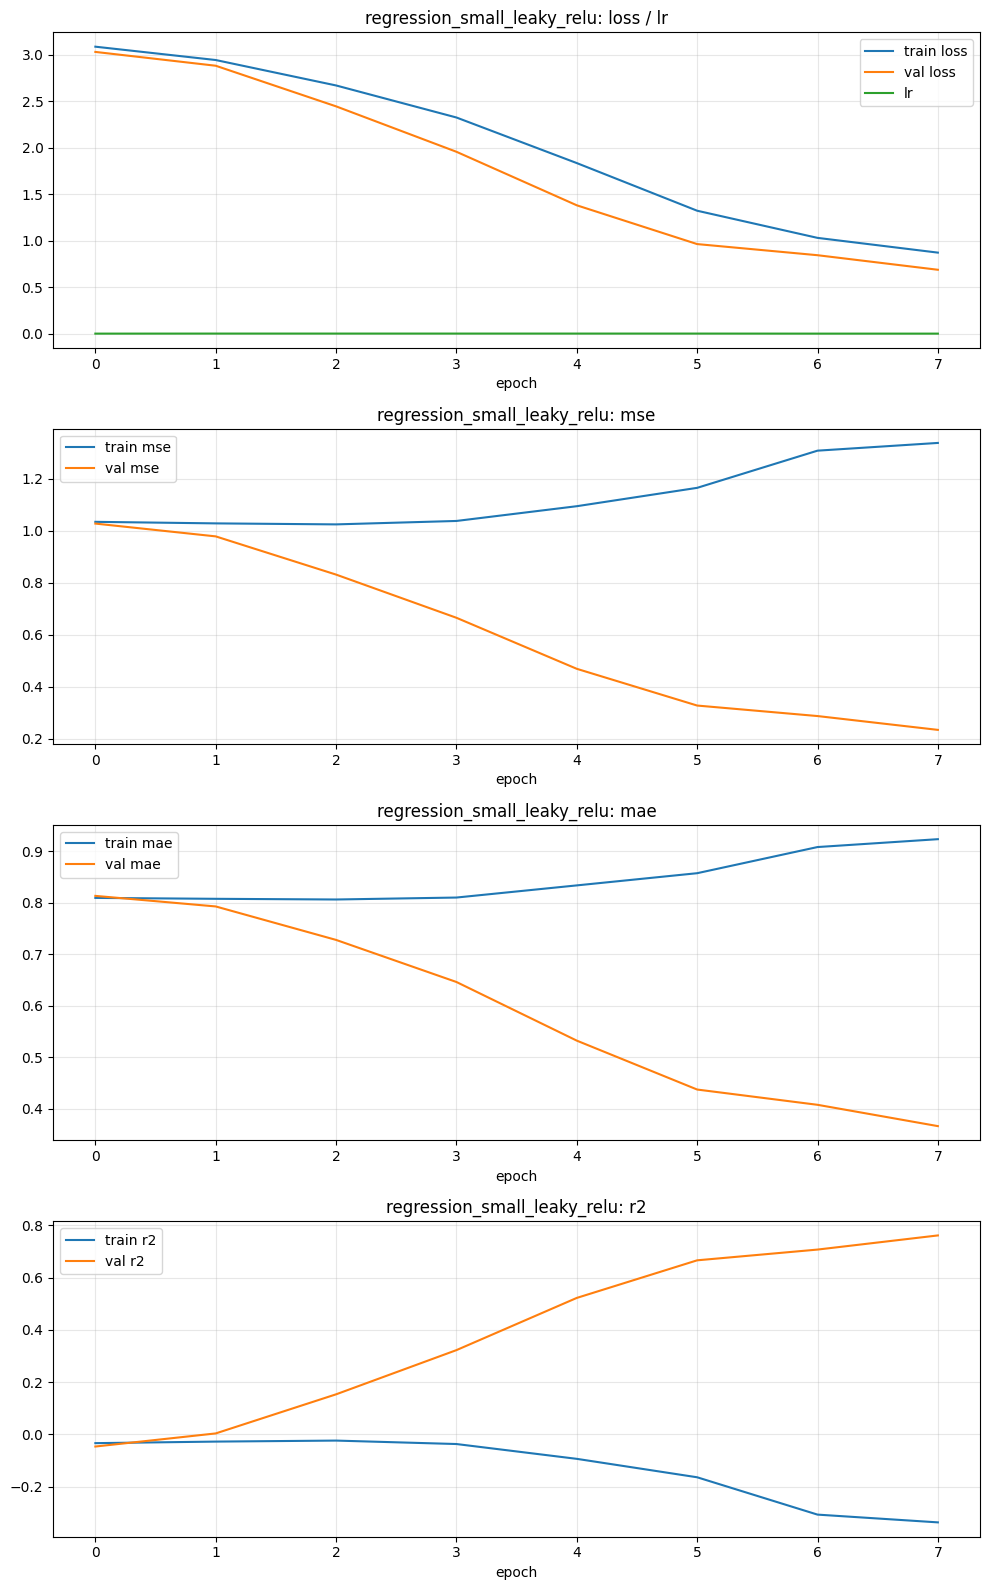


===== regression_small_elu =====
Test metrics (raw targets): MSE=5873.3430, MAE=58.6647, R2=0.8975


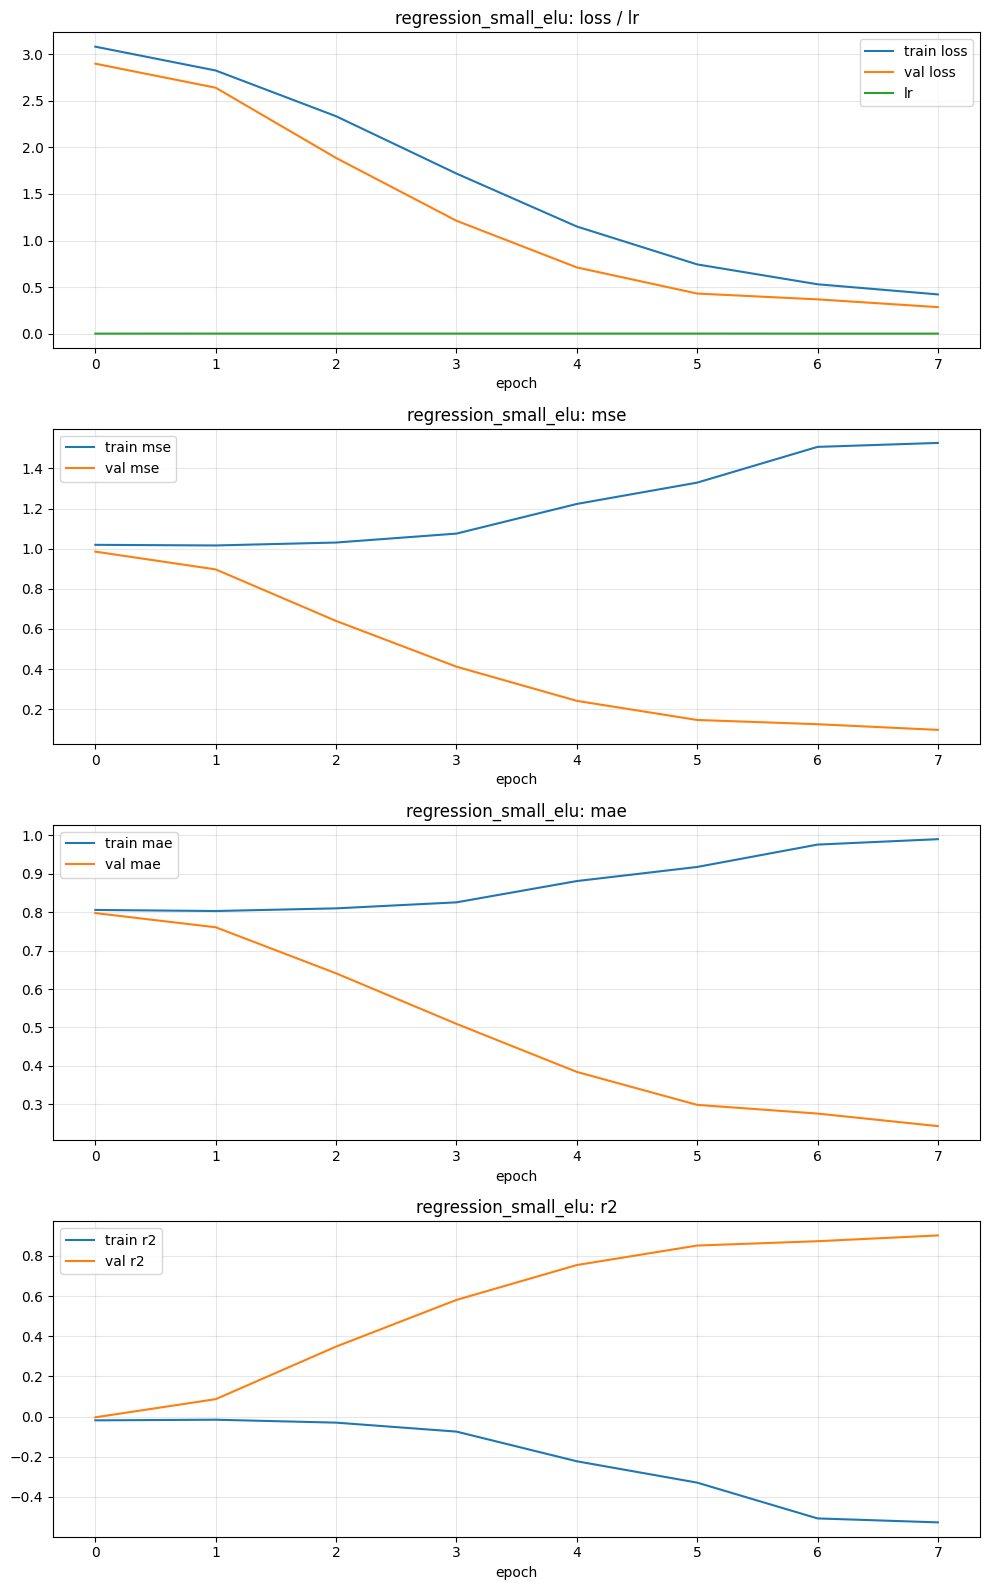


===== regression_medium_relu =====
Test metrics (raw targets): MSE=12132.2122, MAE=84.7125, R2=0.7883


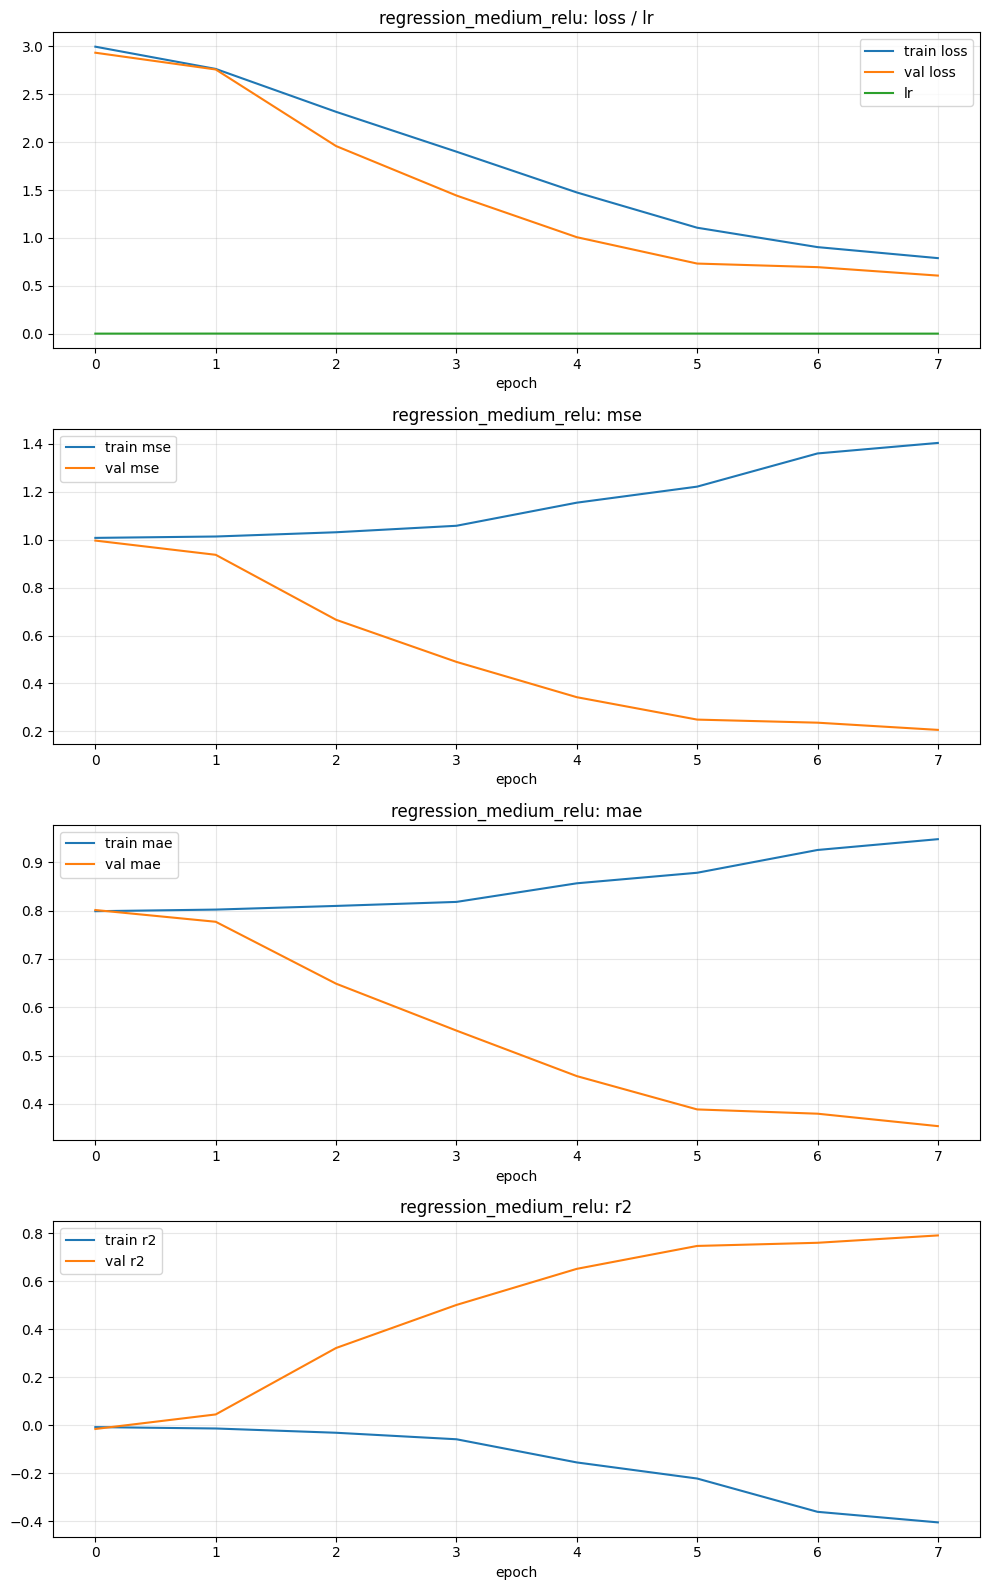


===== regression_medium_leaky_relu =====
Test metrics (raw targets): MSE=11139.5666, MAE=81.9561, R2=0.8056


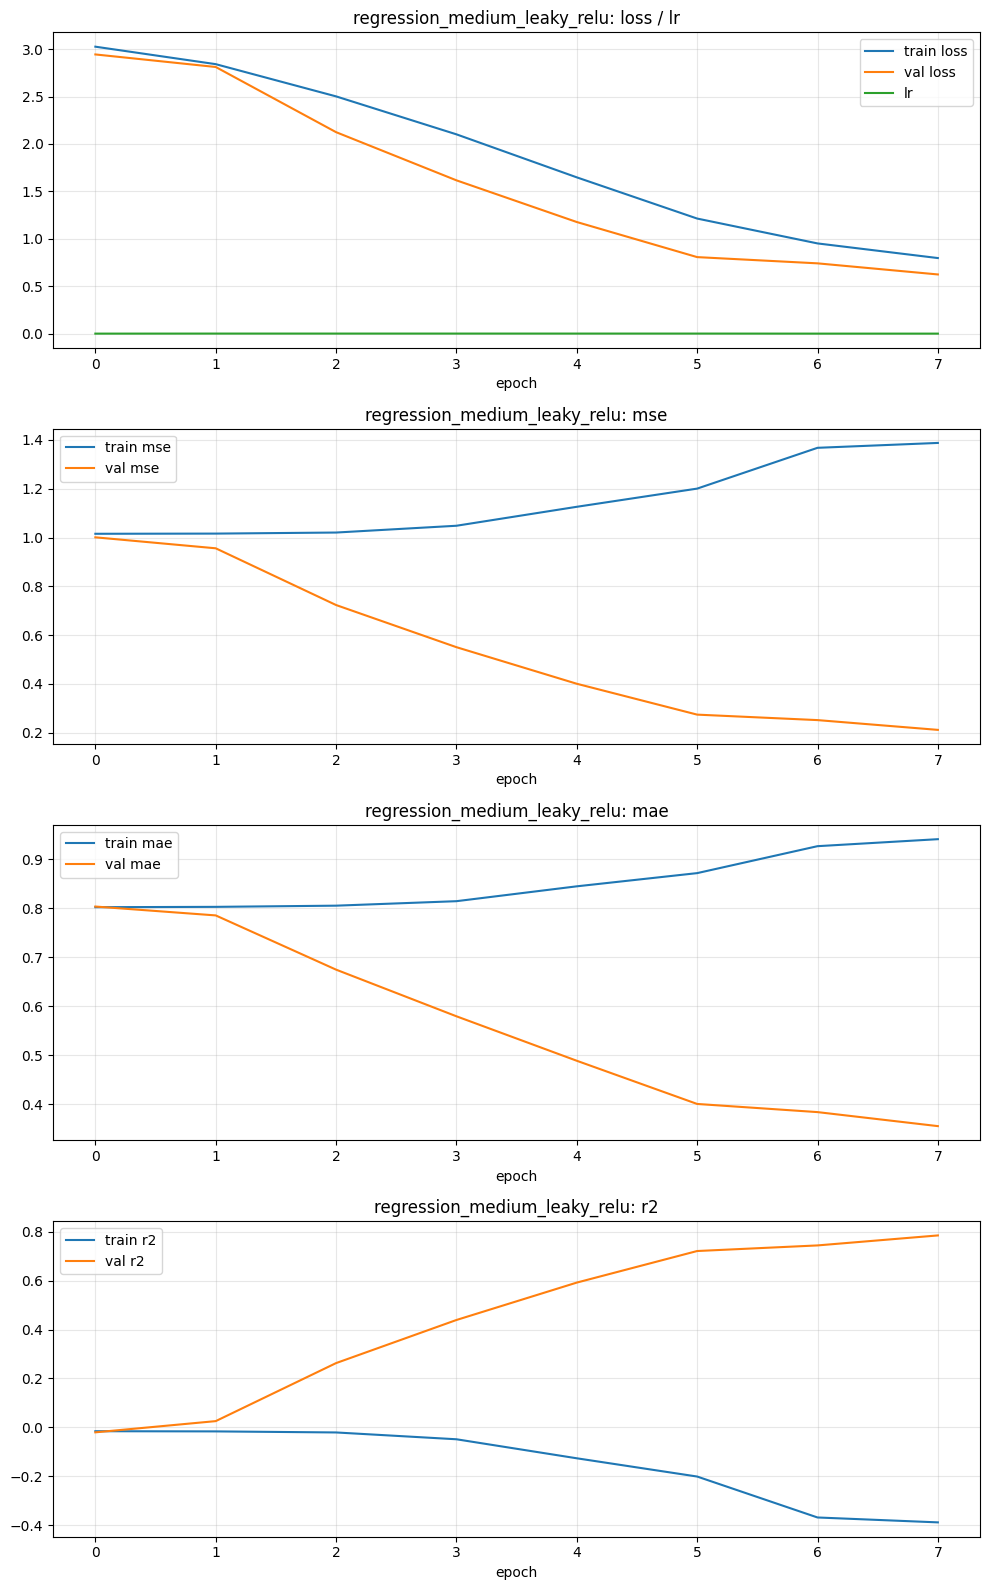


===== regression_medium_elu =====
Test metrics (raw targets): MSE=6606.9780, MAE=62.9162, R2=0.8847


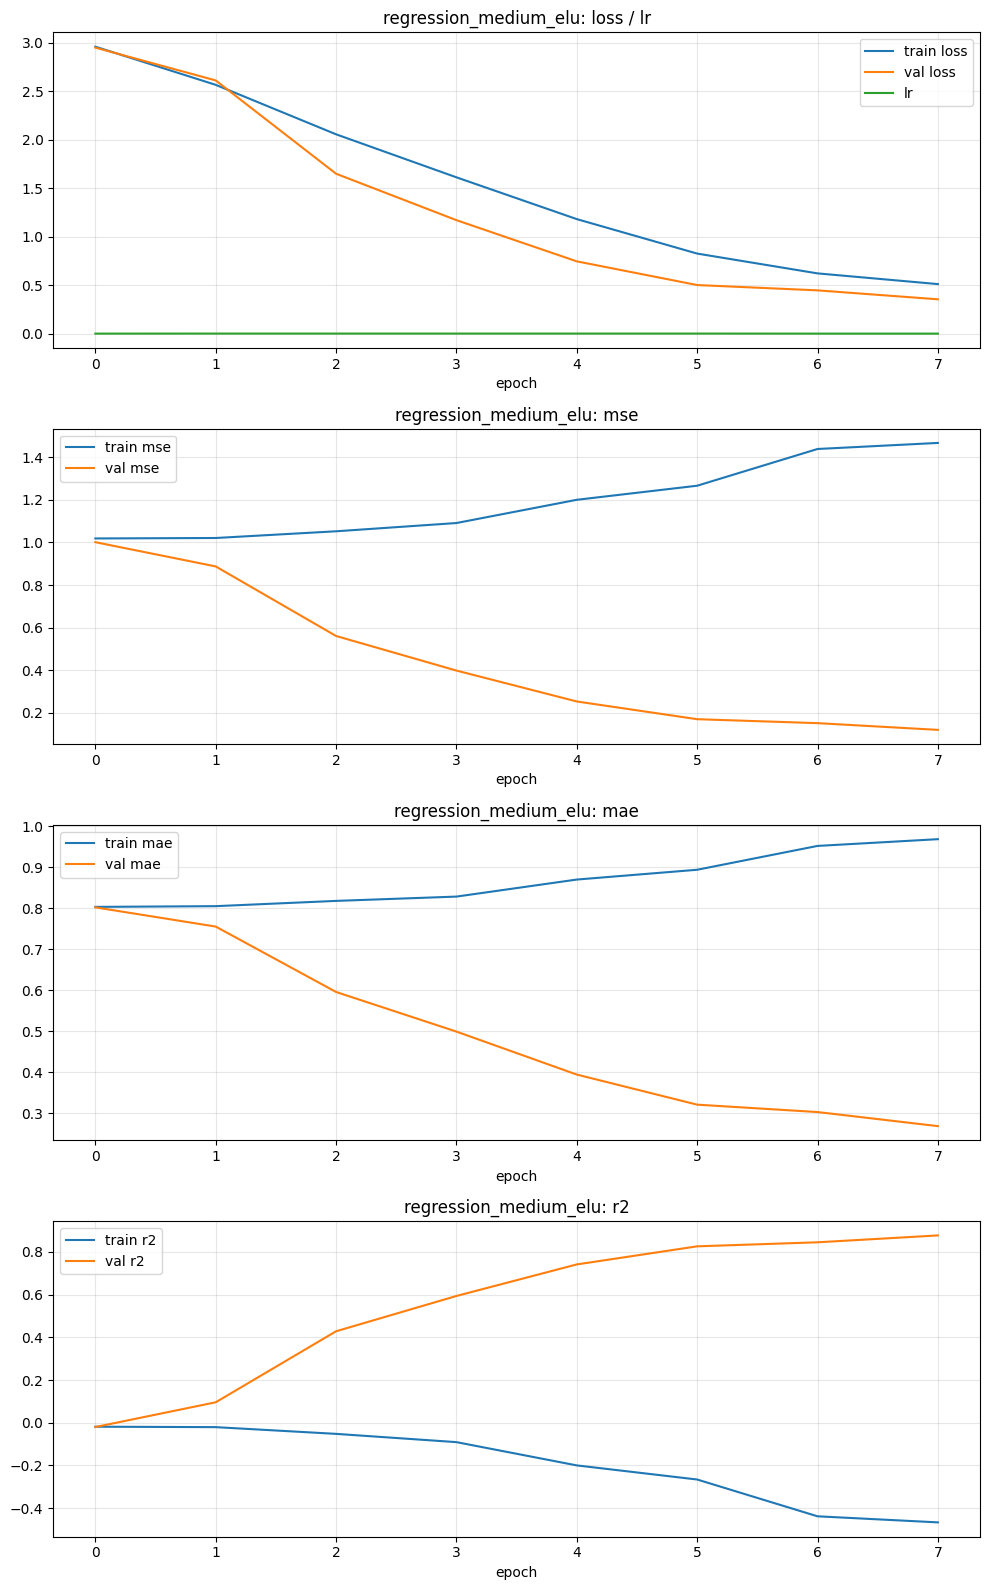


===== regression_large_relu =====
Test metrics (raw targets): MSE=10748.4007, MAE=79.2918, R2=0.8125


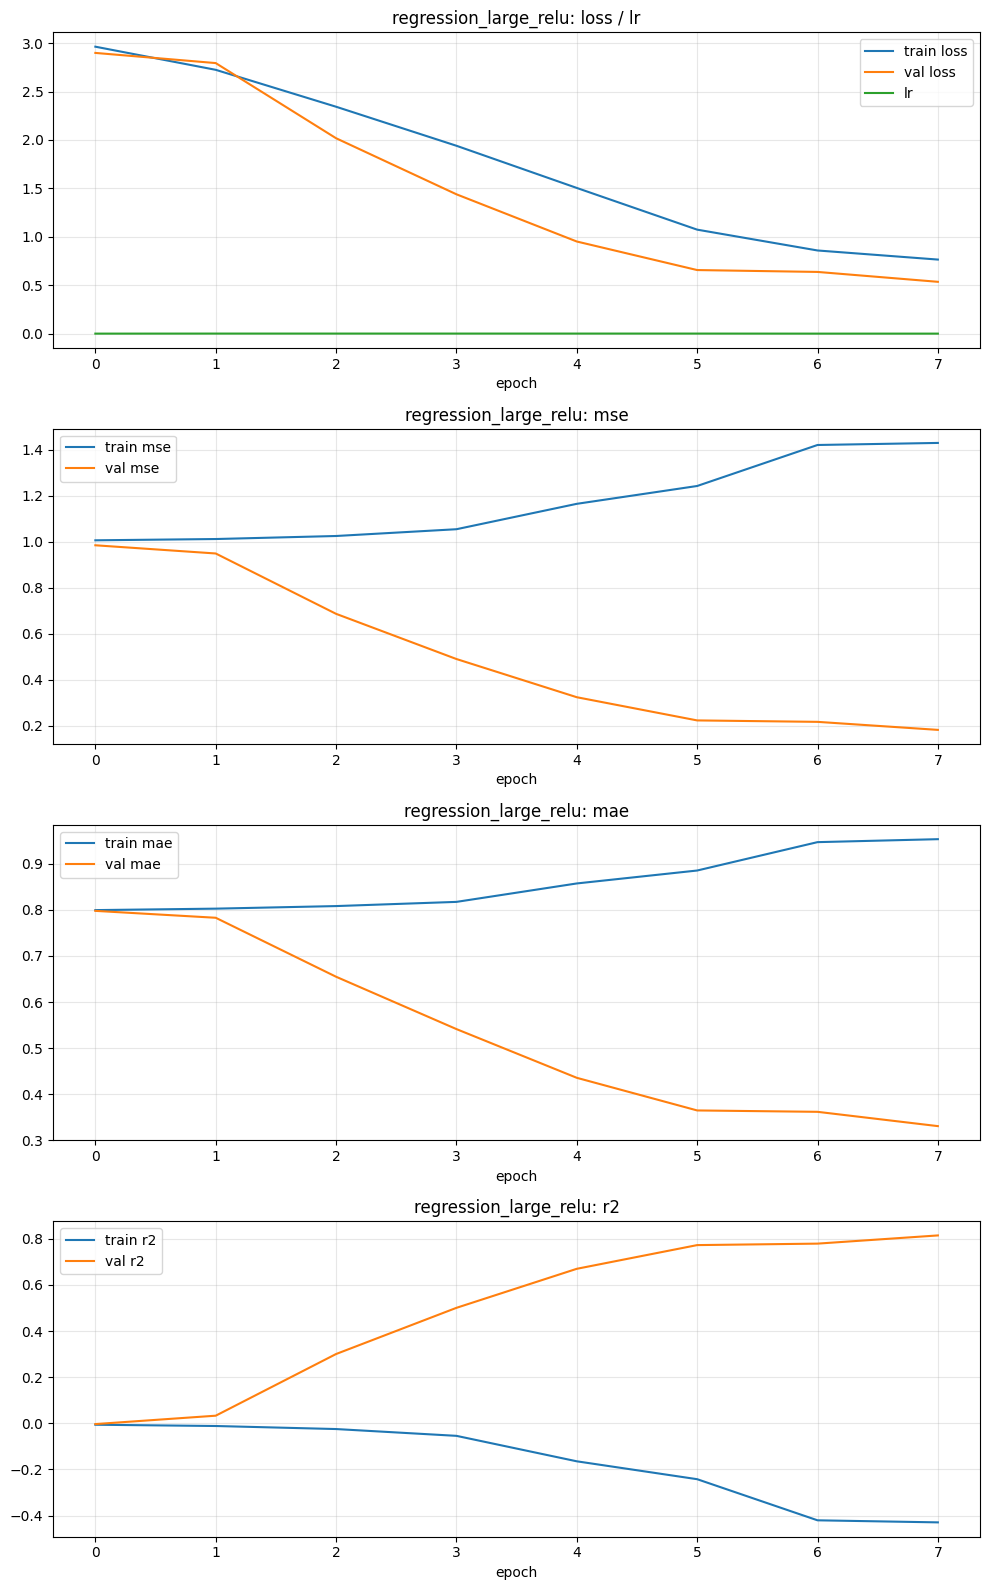


===== regression_large_leaky_relu =====
Test metrics (raw targets): MSE=11504.5588, MAE=82.7839, R2=0.7993


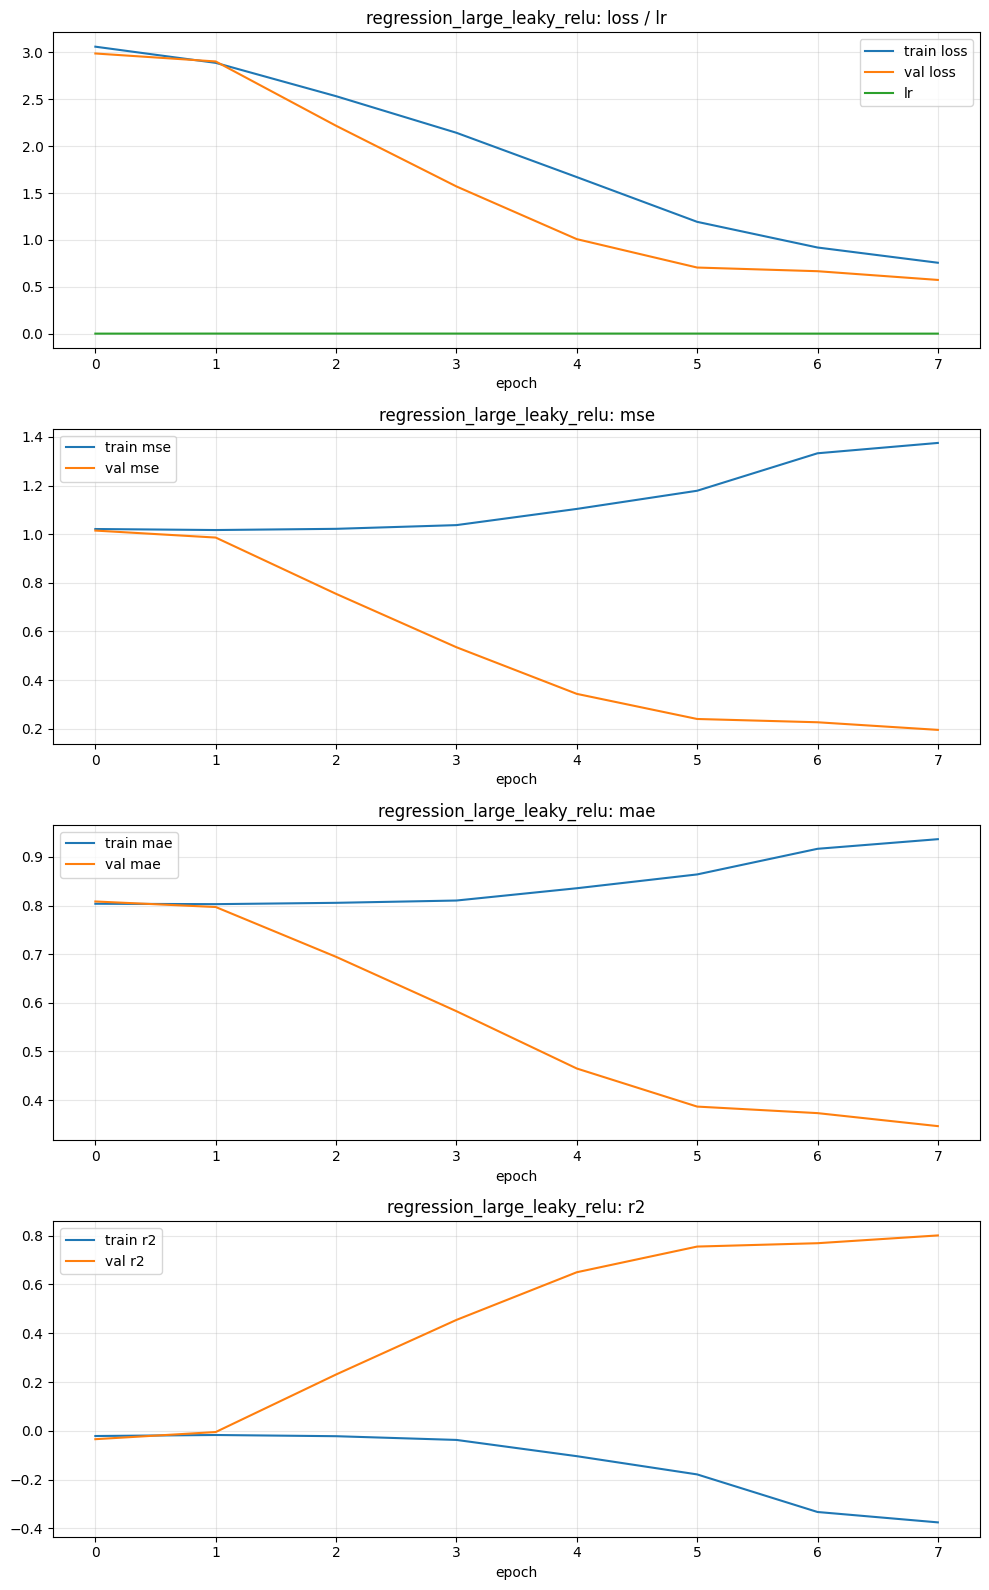


===== regression_large_elu =====
Test metrics (raw targets): MSE=5816.6813, MAE=58.3540, R2=0.8985


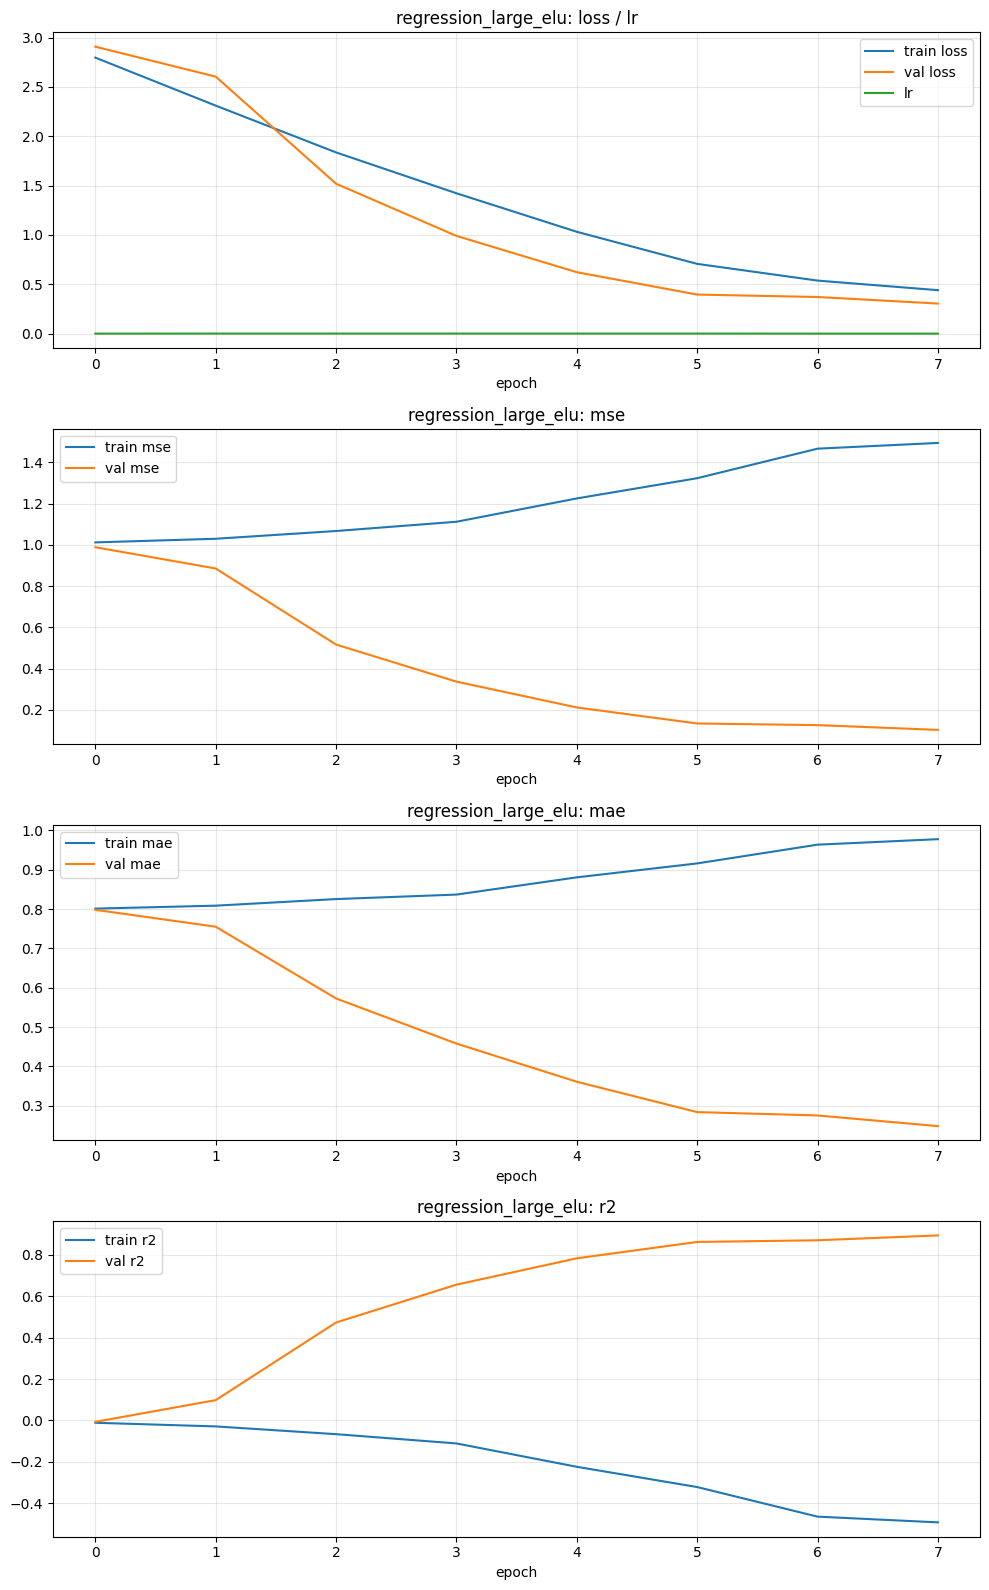

,run,best_epoch,mse,mae,r2
0,regression_large_elu,8,5816.681341,58.353991,0.898517
1,regression_small_elu,8,5873.343027,58.664671,0.897528
2,regression_medium_elu,8,6606.977986,62.916157,0.884728
3,regression_large_relu,8,10748.400747,79.291809,0.812473
4,regression_medium_leaky_relu,8,11139.566631,81.956135,0.805648
5,regression_large_leaky_relu,8,11504.558832,82.783919,0.799280
6,regression_medium_relu,8,12132.212151,84.712516,0.788330
7,regression_small_leaky_relu,8,13833.522993,86.615465,0.758647
8,regression_small_relu,8,18043.627456,102.845843,0.685193


Using dataset: MNIST (torchvision.datasets.MNIST)
Test loss=0.2511, test accuracy=0.9740


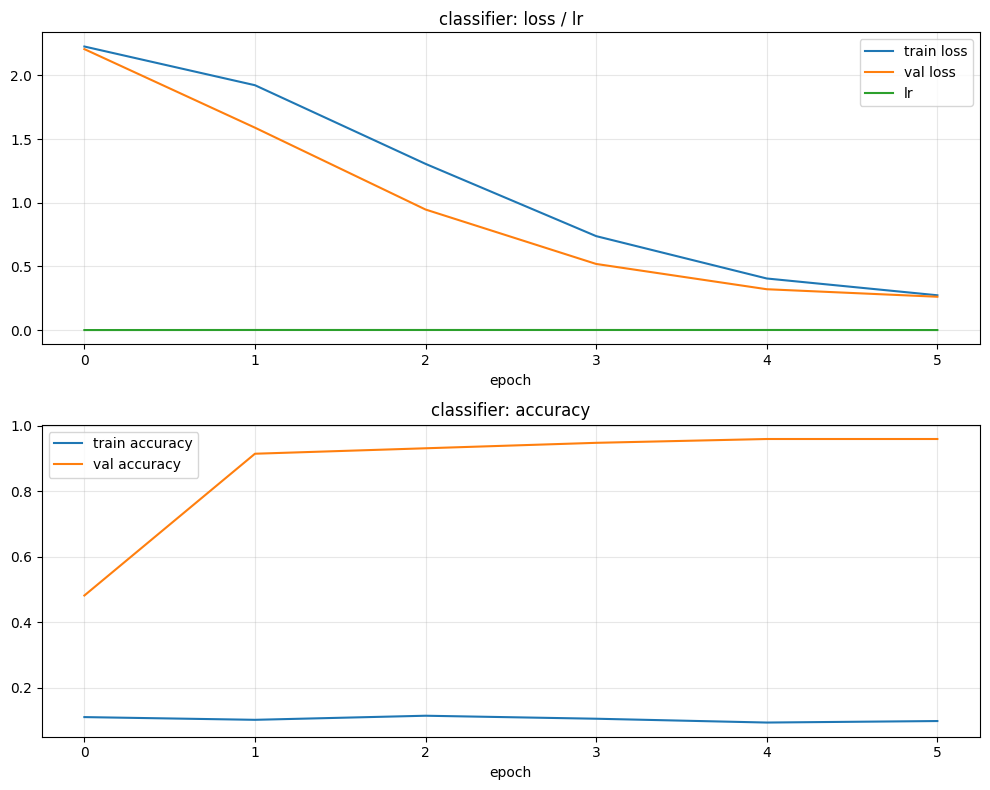

,dataset,best_epoch,loss,accuracy
0,MNIST (torchvision.datasets.MNIST),6,0.251068,0.974


Using dataset: MNIST (torchvision.datasets.MNIST)
Test loss=18.7543, test reconstruction MSE=0.0239


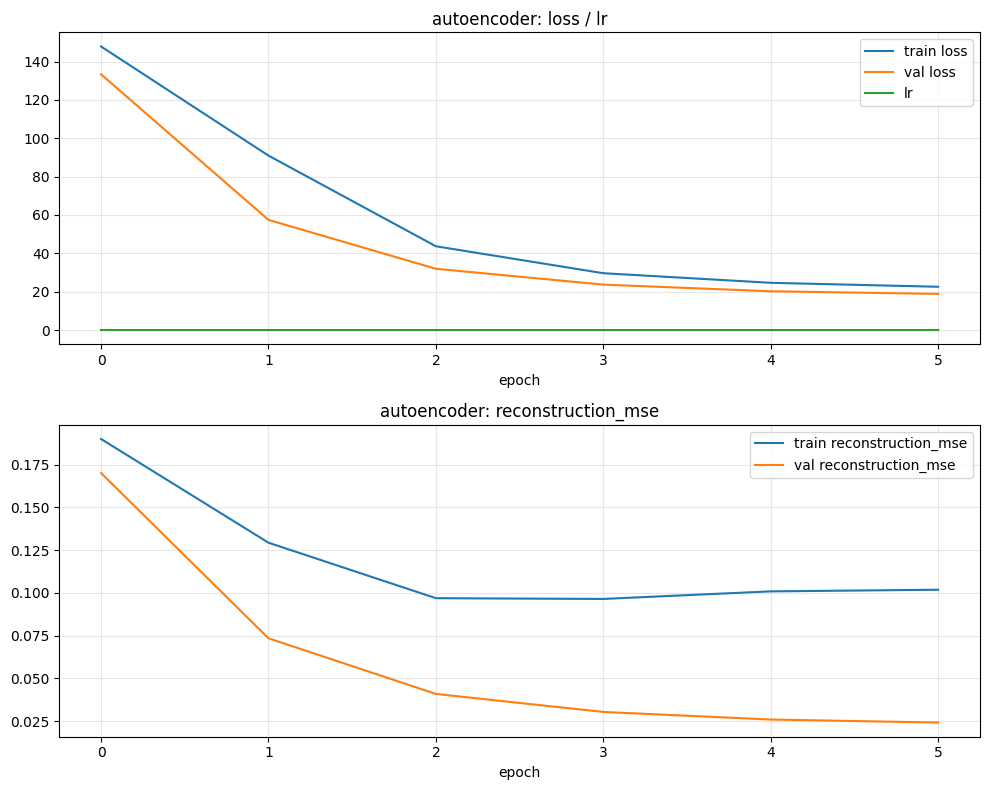

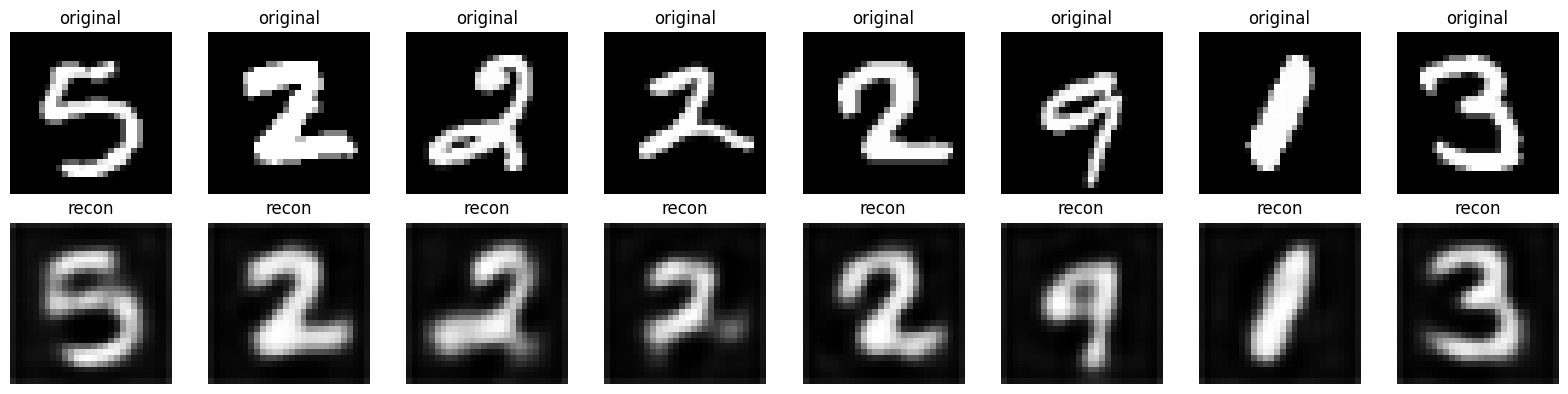

,dataset,best_epoch,loss,reconstruction_mse
0,MNIST (torchvision.datasets.MNIST),6,18.754317,0.023869


In [10]:
SAVE_DIR = 'part2_saved_models'

regression_reports = run_regression_experiments(save_dir=SAVE_DIR, verbose=False)
regression_summary = summarize_regression_reports(regression_reports)
display(regression_summary)

classifier_report = run_classifier_experiment(save_dir=SAVE_DIR, verbose=False)
display(pd.DataFrame([{
    'dataset': classifier_report['dataset_name'],
    'best_epoch': None if classifier_report['best_epoch'] is None else classifier_report['best_epoch'] + 1,
    **classifier_report['test_results'],
}]))

autoencoder_report = run_autoencoder_experiment(save_dir=SAVE_DIR, verbose=False)
display(pd.DataFrame([{
    'dataset': autoencoder_report['dataset_name'],
    'best_epoch': None if autoencoder_report['best_epoch'] is None else autoencoder_report['best_epoch'] + 1,
    **autoencoder_report['test_results'],
}]))

